In [102]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [103]:
agg = pd.read_csv('/Users/shenzhewen/Desktop/walmart_total_weekly.csv')
stores = pd.read_csv('/Users/shenzhewen/Desktop/walmart_three_stores.csv')

agg['Date'] = pd.to_datetime(agg['Date'])
stores['Date'] = pd.to_datetime(stores['Date'])

agg = agg.sort_values('Date').reset_index(drop=True)
stores = stores.sort_values(['Store', 'Date']).reset_index(drop=True)

print('Aggregate shape:', agg.shape)
print('Stores shape:', stores.shape, 'stores=', sorted(stores['Store'].unique().tolist()))
agg.head(3)

Aggregate shape: (143, 7)
Stores shape: (429, 12) stores= [20, 33, 34]


,Date,total_weekly_sales,holiday_share,avg_temp,avg_fuel_price,avg_cpi,avg_unemployment
0,2010-02-05,49750740.50,0.0,34.037333,2.717844,167.730885,8.619311
1,2010-02-12,48336677.63,1.0,34.151333,2.694022,167.825608,8.619311
2,2010-02-19,48276993.78,0.0,37.719778,2.672067,167.871686,8.619311


In [104]:
def smape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = (np.abs(y_true) + np.abs(y_pred))
    mask = denom != 0
    out = np.zeros_like(denom, dtype=float)
    out[mask] = 2 * np.abs(y_pred[mask] - y_true[mask]) / denom[mask]
    return 100 * out.mean()


def metrics_df(y_true, y_pred, label='model'):
    return pd.DataFrame({
        'model': [label],
        'MAE': [mean_absolute_error(y_true, y_pred)],
        'RMSE': [mean_squared_error(y_true, y_pred) ** 0.5],
        'sMAPE': [smape(y_true, y_pred)]
    })


def rolling_cv_hw(y, trend='add', seasonal='add', seasonal_periods=52, min_train=80):
    preds, actual, dates = [], [], []

    for t in range(min_train, len(y)):
        y_tr = y.iloc[:t]
        y_te = y.iloc[t:t+1]

        try:
            m = ExponentialSmoothing(
                y_tr,
                trend=trend,
                seasonal=seasonal,
                seasonal_periods=seasonal_periods
            ).fit(optimized=True)

            p = m.forecast(1).iloc[0]
            preds.append(p)
            actual.append(y_te.iloc[0])
            dates.append(y_te.index[0])

        except Exception:
            continue

    pred_s = pd.Series(preds, index=dates, name='pred')
    act_s = pd.Series(actual, index=dates, name='actual')
    return act_s, pred_s

def fit_holt_winters(
    df,
    date_col,
    target_col,
    test_size=24,
    trend='add',
    seasonal='add',
    seasonal_periods=52,
    use_log=False,
    min_train=80
):
    # 1) prepare data
    d = df.copy().sort_values(date_col)
    d = d[[date_col, target_col]].dropna().reset_index(drop=True)
    d[date_col] = pd.to_datetime(d[date_col])
    d = d.set_index(date_col)

    y_raw = d[target_col].astype(float)

    # optional log transform
    if use_log:
        y = np.log1p(y_raw)
    else:
        y = y_raw.copy()

    # 2) train / test split
    train_n = len(d) - test_size
    y_tr = y.iloc[:train_n]
    y_te = y.iloc[train_n:]

    # 3) fit model
    model = ExponentialSmoothing(
        y_tr,
        trend=trend,
        seasonal=seasonal,
        seasonal_periods=seasonal_periods,
        initialization_method="estimated"
    ).fit(optimized=True)

    # 4) in-sample fitted + out-of-sample forecast
    pred_tr = model.fittedvalues
    pred_te = model.forecast(len(y_te))

    # 5) transform back for evaluation
    if use_log:
        y_tr_eval = np.expm1(y_tr)
        y_te_eval = np.expm1(y_te)
        pred_tr_eval = np.expm1(pred_tr)
        pred_te_eval = np.expm1(pred_te)
    else:
        y_tr_eval = y_tr.copy()
        y_te_eval = y_te.copy()
        pred_tr_eval = pred_tr.copy()
        pred_te_eval = pred_te.copy()

    # 6) metrics
    train_metrics = metrics_df(y_tr_eval, pred_tr_eval, label='train')
    test_metrics = metrics_df(y_te_eval, pred_te_eval, label='test')

    # 7) rolling CV
    act_cv, pred_cv = rolling_cv_hw(
        y,
        trend=trend,
        seasonal=seasonal,
        seasonal_periods=seasonal_periods,
        min_train=min_train
    )

    if use_log:
        act_cv_eval = np.expm1(act_cv)
        pred_cv_eval = np.expm1(pred_cv)
    else:
        act_cv_eval = act_cv.copy()
        pred_cv_eval = pred_cv.copy()

    rolling_cv_metrics = metrics_df(act_cv_eval, pred_cv_eval, label='rolling_cv')

    # 8) residual diagnostics
    resid = y_tr - pred_tr
    lb = acorr_ljungbox(resid.dropna(), lags=[8, 12], return_df=True)

    # 9) output
    out = {
        'data': d,
        'model': model,
        'y_train': y_tr_eval,
        'y_test': y_te_eval,
        'pred_train': pred_tr_eval,
        'pred_test': pred_te_eval,
        'train_metrics': train_metrics,
        'test_metrics': test_metrics,
        'rolling_cv_actual': act_cv_eval,
        'rolling_cv_pred': pred_cv_eval,
        'rolling_cv_metrics': rolling_cv_metrics,
        'residuals': resid,
        'ljung_box': lb,
        'trend': trend,
        'seasonal': seasonal,
        'seasonal_periods': seasonal_periods,
        'use_log': use_log,
    }

    return out

## total

In [105]:
hw_total = fit_holt_winters(
    agg,
    date_col='Date',
    target_col='total_weekly_sales',
    test_size=24,
    trend='add',
    seasonal='add',
    seasonal_periods=52,
    use_log=False,
    min_train=80
)

## 3 representative store

In [106]:
store_results = {}

for store_id in [20, 33, 34]:
    store_df = stores[stores["Store"] == store_id].copy()

    store_results[store_id] = fit_holt_winters(
        store_df,
        date_col='Date',
        target_col='Weekly_Sales',
        test_size=24,
        trend='add',
        seasonal='add',
        seasonal_periods=52,
        use_log=False,
        min_train=80
    )

In [107]:
hw_high = store_results[20]
hw_low = store_results[33]
hw_mid = store_results[34]

## summary statistic

In [108]:
summary = pd.concat([
    hw_total['train_metrics'].assign(dataset='total'),
    hw_total['test_metrics'].assign(dataset='total'),
    hw_total['rolling_cv_metrics'].assign(dataset='total'),

    hw_high['train_metrics'].assign(dataset='high_store'),
    hw_high['test_metrics'].assign(dataset='high_store'),
    hw_high['rolling_cv_metrics'].assign(dataset='high_store'),

    hw_mid['train_metrics'].assign(dataset='mid_store'),
    hw_mid['test_metrics'].assign(dataset='mid_store'),
    hw_mid['rolling_cv_metrics'].assign(dataset='mid_store'),

    hw_low['train_metrics'].assign(dataset='low_store'),
    hw_low['test_metrics'].assign(dataset='low_store'),
    hw_low['rolling_cv_metrics'].assign(dataset='low_store'),
], ignore_index=True)

summary = summary[['dataset', 'model', 'MAE', 'RMSE', 'sMAPE']]
print(summary)

       dataset       model           MAE          RMSE     sMAPE
0        total       train  8.762409e+05  1.479265e+06  1.831456
1        total        test  9.264820e+05  1.146543e+06  1.954456
2        total  rolling_cv  1.166431e+06  1.750060e+06  2.448243
3   high_store       train  6.454539e+04  1.101881e+05  3.001403
4   high_store        test  6.648071e+04  8.461334e+04  3.178062
5   high_store  rolling_cv  9.510750e+04  1.450371e+05  4.442923
6    mid_store       train  1.773425e+04  3.037894e+04  1.815933
7    mid_store        test  2.962920e+04  3.540604e+04  3.110012
8    mid_store  rolling_cv  2.856986e+04  3.702129e+04  2.901595
9    low_store       train  6.939240e+03  9.989748e+03  2.623517
10   low_store        test  1.686485e+04  2.111210e+04  6.544571
11   low_store  rolling_cv  1.115974e+04  1.415387e+04  4.167304


In [109]:
summary = pd.concat([
    hw_total['train_metrics'].assign(dataset='total'),
    hw_total['test_metrics'].assign(dataset='total'),

    hw_high['train_metrics'].assign(dataset='high_store'),
    hw_high['test_metrics'].assign(dataset='high_store'),

    hw_mid['train_metrics'].assign(dataset='mid_store'),
    hw_mid['test_metrics'].assign(dataset='mid_store'),

    hw_low['train_metrics'].assign(dataset='low_store'),
    hw_low['test_metrics'].assign(dataset='low_store'),
], ignore_index=True)

summary = summary[['dataset', 'model', 'MAE', 'RMSE', 'sMAPE']]
print(summary)

      dataset  model            MAE          RMSE     sMAPE
0       total  train  876240.917492  1.479265e+06  1.831456
1       total   test  926481.976516  1.146543e+06  1.954456
2  high_store  train   64545.393555  1.101881e+05  3.001403
3  high_store   test   66480.708859  8.461334e+04  3.178062
4   mid_store  train   17734.251609  3.037894e+04  1.815933
5   mid_store   test   29629.202969  3.540604e+04  3.110012
6   low_store  train    6939.239829  9.989748e+03  2.623517
7   low_store   test   16864.848072  2.111210e+04  6.544571


Overall model performance is strong.

Total sales forecasting achieved sMAPE around 2–2.5%, indicating accurate seasonal trend capture.

High-volume and mid-volume stores show stable generalization between training and testing sets.

The low-volume store exhibits higher test error due to greater relative volatility in smaller sales volumes.

Rolling cross-validation error is slightly higher than the test error, which is expected since the model is repeatedly refit on smaller training windows.

## plot forcast

In [110]:
def plot_hw_result(res, title='Holt-Winters Forecast'):
    plt.figure(figsize=(12, 5))
    plt.plot(res['y_train'].index, res['y_train'], label='Train')
    plt.plot(res['y_test'].index, res['y_test'], label='Test')
    plt.plot(res['pred_test'].index, res['pred_test'], label='Forecast')
    plt.title(title)
    plt.xlabel('Date')
    plt.ylabel('Weekly Sales')
    plt.legend()
    plt.show()

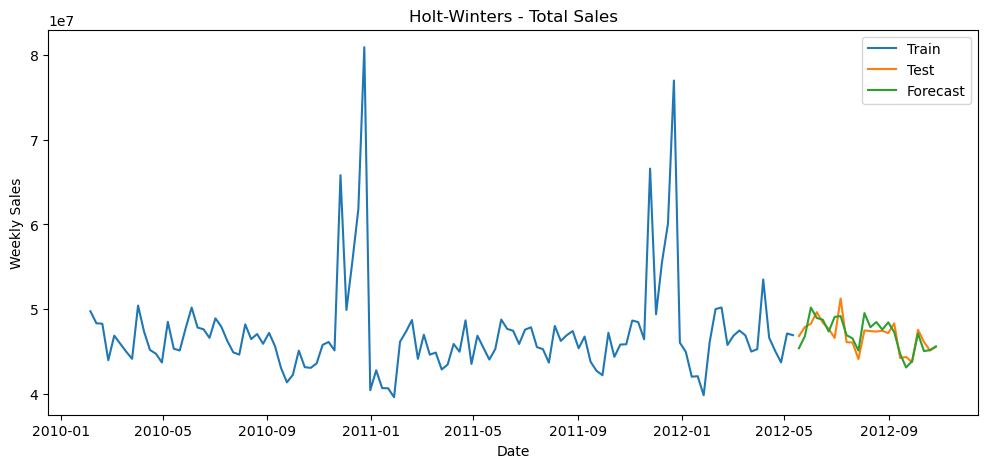

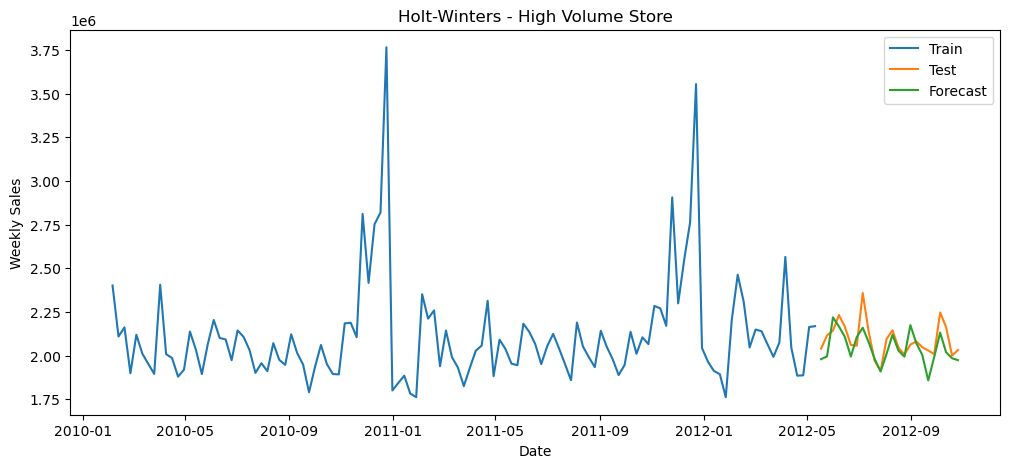

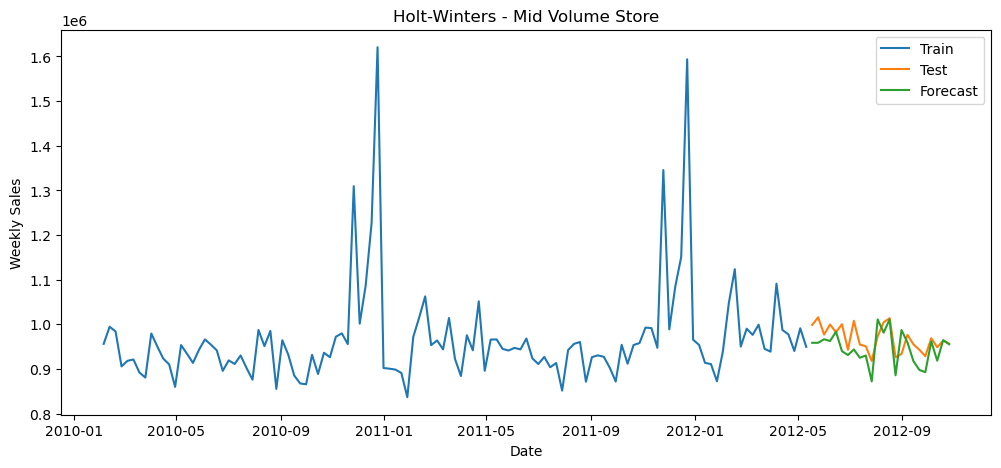

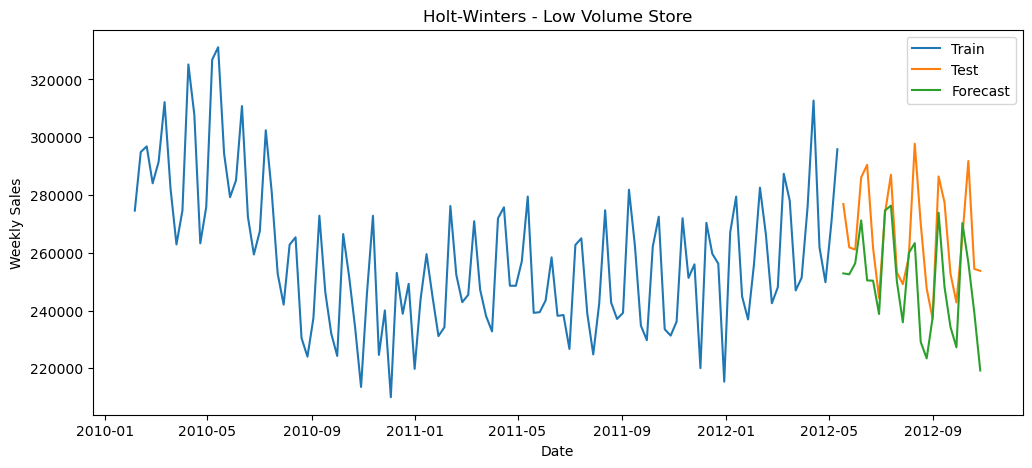

In [111]:
plot_hw_result(hw_total, title='Holt-Winters - Total Sales')
plot_hw_result(hw_high, title='Holt-Winters - High Volume Store')
plot_hw_result(hw_mid, title='Holt-Winters - Mid Volume Store')
plot_hw_result(hw_low, title='Holt-Winters - Low Volume Store')

## residual check

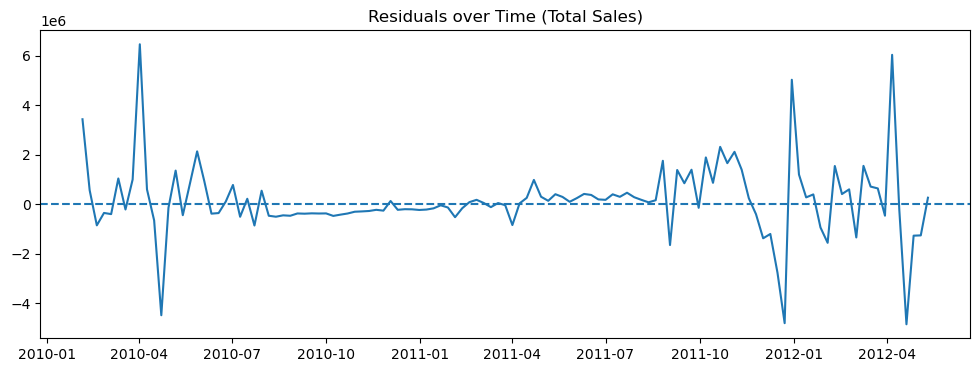

In [112]:
resid = hw_total['residuals']

plt.figure(figsize=(12,4))
plt.plot(resid)
plt.axhline(0, linestyle='--')
plt.title("Residuals over Time (Total Sales)")
plt.show()

In [113]:
hw_high['ljung_box']

,lb_stat,lb_pvalue
8,8.961857,0.345524
12,11.626887,0.476091


white noise

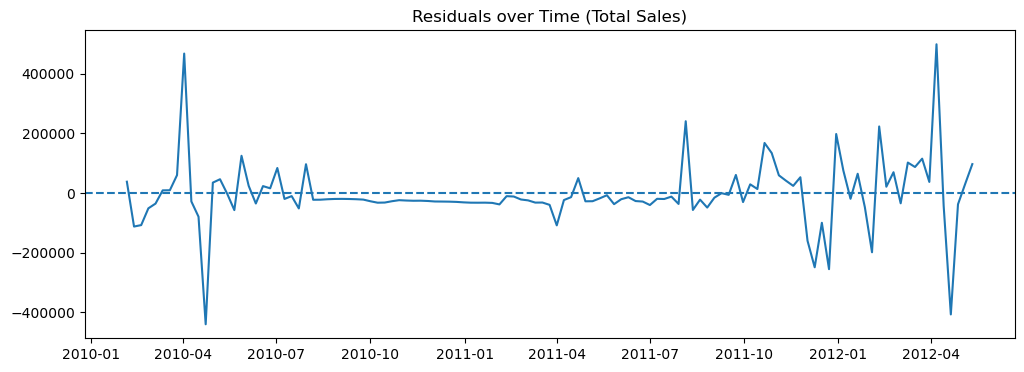

In [114]:
resid = hw_high['residuals']

plt.figure(figsize=(12,4))
plt.plot(resid)
plt.axhline(0, linestyle='--')
plt.title("Residuals over Time (Total Sales)")
plt.show()

In [115]:
hw_high['ljung_box']

,lb_stat,lb_pvalue
8,8.961857,0.345524
12,11.626887,0.476091


white noise

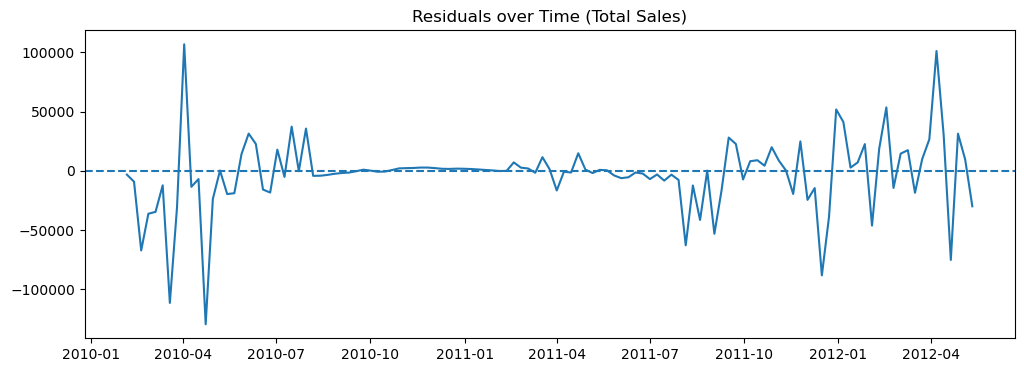

In [116]:
resid = hw_mid['residuals']

plt.figure(figsize=(12,4))
plt.plot(resid)
plt.axhline(0, linestyle='--')
plt.title("Residuals over Time (Total Sales)")
plt.show()

In [117]:
hw_mid['ljung_box']

,lb_stat,lb_pvalue
8,9.206281,0.325194
12,11.754139,0.465622


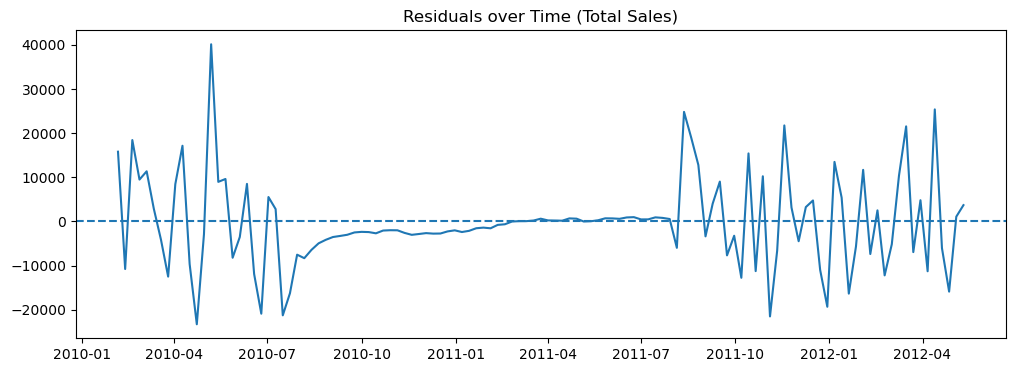

In [118]:
resid = hw_low['residuals']

plt.figure(figsize=(12,4))
plt.plot(resid)
plt.axhline(0, linestyle='--')
plt.title("Residuals over Time (Total Sales)")
plt.show()

In [119]:
hw_low['ljung_box']

,lb_stat,lb_pvalue
8,18.163972,0.020030
12,22.265232,0.034653


not white noise!

Holt-Winters is a univariate model and does not incorporate exogenous variables such as temperature, fuel price, or holiday effects. We could explore SARIMAX or machine learning approaches that incorporate these external drivers.

## including holiday season

In [120]:
holiday_train_start = "2010-02-05"
holiday_train_end   = "2011-10-28"

holiday_test_start  = "2011-11-04"
holiday_test_end    = "2011-12-30"

In [121]:
df = agg.copy().sort_values("Date")
df["Date"] = pd.to_datetime(df["Date"])
df = df.set_index("Date")

train_holiday = df.loc[holiday_train_start:holiday_train_end]
test_holiday  = df.loc[holiday_test_start:holiday_test_end]

y_train = train_holiday["total_weekly_sales"]
y_test  = test_holiday["total_weekly_sales"]

In [125]:
#hw_holiday = ExponentialSmoothing(
   # y_train,
   # trend="add",
   # seasonal="add",
   # seasonal_periods=52,
   # initialization_method="estimated"
#).fit(optimized=True)

In [126]:
from sklearn.ensemble import RandomForestRegressor

df = agg.copy().sort_values("Date")
df["Date"] = pd.to_datetime(df["Date"])

# lag features
df["lag1"] = df["total_weekly_sales"].shift(1)
df["lag2"] = df["total_weekly_sales"].shift(2)
df["lag4"] = df["total_weekly_sales"].shift(4)
df["lag52"] = df["total_weekly_sales"].shift(52)

df = df.dropna()

features = [
    "lag1","lag2","lag4","lag52",
    "holiday_share",
    "avg_temp",
    "avg_fuel_price",
    "avg_cpi",
    "avg_unemployment"
]

target = "total_weekly_sales"

train = df[(df["Date"] >= "2010-02-05") & (df["Date"] <= "2011-10-28")]
test  = df[(df["Date"] >= "2011-11-04") & (df["Date"] <= "2011-12-30")]

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)

pred = rf.predict(X_test)

In [127]:
holiday_metrics = metrics_df(y_test, pred, label="RF_holiday_backtest")
print(holiday_metrics)

                 model           MAE          RMSE      sMAPE
0  RF_holiday_backtest  9.385652e+06  1.380047e+07  16.877008


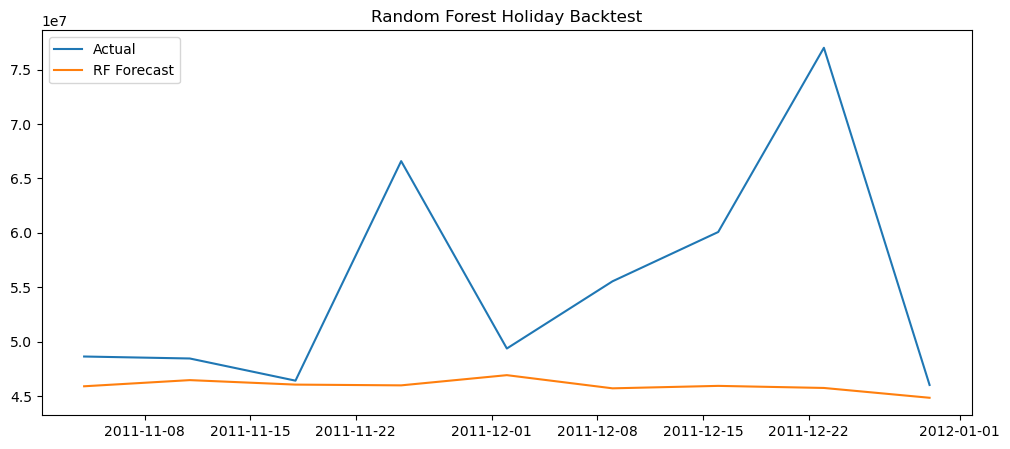

In [128]:
plt.figure(figsize=(12,5))

plt.plot(test["Date"], y_test, label="Actual")
plt.plot(test["Date"], pred, label="RF Forecast")

plt.title("Random Forest Holiday Backtest")
plt.legend()
plt.show()

In [130]:
df = agg.copy().sort_values("Date")
df["Date"] = pd.to_datetime(df["Date"])
df = df.set_index("Date")

y_full = df["total_weekly_sales"]

hw_final = ExponentialSmoothing(
    y_full,
    trend="add",
    seasonal="add",
    seasonal_periods=52,
    initialization_method="estimated"
).fit(optimized=True)

In [131]:
future_steps = 12

future_forecast = hw_final.forecast(future_steps)

print(future_forecast)

2012-11-02    4.780135e+07
2012-11-09    4.806464e+07
2012-11-16    4.690759e+07
2012-11-23    6.755493e+07
2012-11-30    5.148422e+07
2012-12-07    5.735594e+07
2012-12-14    6.328325e+07
2012-12-21    8.209822e+07
2012-12-28    4.321566e+07
2013-01-04    4.498114e+07
2013-01-11    4.275582e+07
2013-01-18    4.276633e+07
Freq: W-FRI, dtype: float64


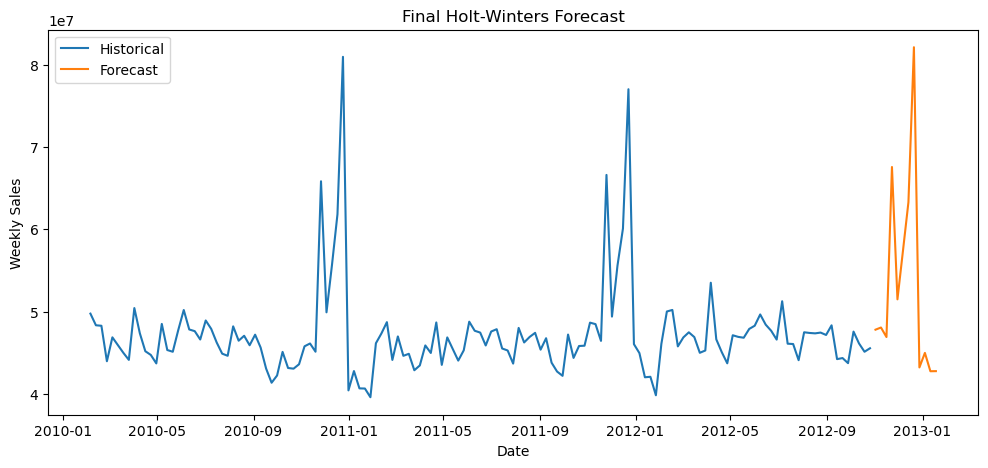

In [132]:
plt.figure(figsize=(12,5))

plt.plot(y_full.index, y_full, label="Historical")
plt.plot(future_forecast.index, future_forecast, label="Forecast")

plt.title("Final Holt-Winters Forecast")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")

plt.legend()
plt.show()